<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/8_Neural_Networks_for_Classification_Problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Softmax Regression

In the previous chapter, we studied **linear regression**, which predicts a **continuous numerical value**. For example, a linear regression model can estimate the price of a house, the number of days a patient stays in the hospital, or the number of products a customer may purchase.

Many real-world problems, however, require predicting **categories** instead of numerical values. This type of supervised learning task is known as **classification**.

For example, a classification model may answer questions such as:

- Is this email **spam** or **not spam**?
- Does this image contain a **cat**, **dog**, or **horse**?
- Will a customer **subscribe** to a service?
- Which handwritten digit (0–9) does this image represent?

Unlike regression, which predicts continuous values, classification predicts one of several predefined classes.

In this chapter, we introduce **softmax regression**, a linear model designed for **multiclass classification**. Softmax regression extends linear regression by producing a probability for each possible class. The class with the highest probability is selected as the model's prediction.

As in the previous chapter, we will first develop the model step by step before implementing the same classifier using TensorFlow's high-level Keras API.

Classification

To understand classification, consider a simple image recognition task. Suppose each input is a small grayscale image represented by four pixel values:

$$
\mathbf{x} = [x_1, x_2, x_3, x_4].
$$

Our goal is to determine which category the image belongs to. For example, each image may represent one of three classes:

- Cat
- Chicken
- Dog

Unlike linear regression, which predicts a continuous value, a classification model predicts the **class** to which an input belongs.

### Representing Class Labels

Before training a classification model, we must decide how to represent the class labels.

A simple approach is to assign an integer to each class:

| Class | Integer Label |
|:------|:-------------:|
| Cat | 0 |
| Chicken | 1 |
| Dog | 2 |

Although integer labels are easy to store, they may incorrectly suggest that the classes have a numerical relationship. For example, the label **2** is not "greater" or "better" than **1**—it simply represents a different category.

For this reason, classification models commonly represent labels using **one-hot encoding**.

### One-Hot Encoding

A **one-hot encoded** label is a binary vector whose length equals the number of classes. The correct class is represented by **1**, while all other classes are represented by **0**.

For our three classes:

| Class | One-Hot Encoding |
|:------|:----------------:|
| Cat | (1, 0, 0) |
| Chicken | (0, 1, 0) |
| Dog | (0, 0, 1) |

Mathematically,

$$
\mathbf{y} \in
\{
(1,0,0),\,
(0,1,0),\,
(0,0,1)
\}.
$$

One-hot encoding allows the model to produce a probability for every possible class, making it the standard representation for multiclass classification.

## Linear Model for Classification

Unlike linear regression, which predicts a single value, a classification model must produce one output for each possible class.

For our example with three classes (cat, chicken, and dog), the model computes three output scores:

$$
o_1,\;o_2,\;o_3.
$$

Each score is computed using a linear equation with its own weights and bias:

$$
\begin{aligned}
o_1 &= x_1w_{11}+x_2w_{12}+x_3w_{13}+x_4w_{14}+b_1,\\
o_2 &= x_1w_{21}+x_2w_{22}+x_3w_{23}+x_4w_{24}+b_2,\\
o_3 &= x_1w_{31}+x_2w_{32}+x_3w_{33}+x_4w_{34}+b_3.
\end{aligned}
$$

This architecture forms a **fully connected (Dense) layer**, where every input feature is connected to every output.

Rather than writing separate equations for each class, we can express the model more compactly as

$$
\mathbf{o}=W\mathbf{x}+\mathbf{b}.
$$

The outputs are **scores**, not probabilities. In the next section, we will use the **Softmax** function to convert these scores into probabilities.

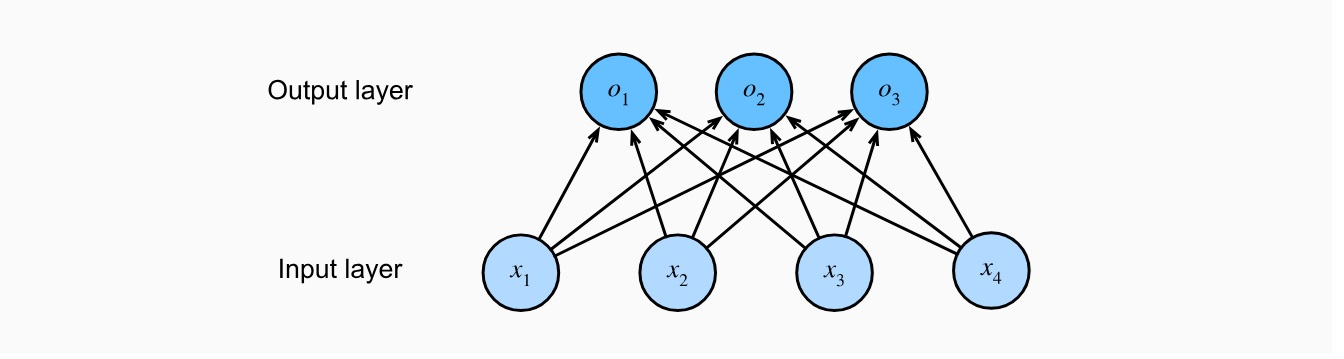

The Softmax Function

The linear model produces an output vector of **scores**:

$$
\mathbf{o}=[o_1,o_2,\ldots,o_n].
$$

These scores are **not probabilities** because:

- They may be negative.
- They may be greater than 1.
- Their sum is not necessarily equal to 1.

To convert these scores into probabilities, we apply the **Softmax** function.

For class $i$, the probability is

$$
\hat{y}_i=
\frac{e^{o_i}}
{\sum_{j=1}^{n}e^{o_j}}.
$$

where

- $o_i$ is the score produced by the linear model for class $i$.
- $e^{o_i}$ converts the score into a positive value.
- $\sum_{j=1}^{n}e^{o_j}$ is the sum of the exponentials of all class scores.
- Dividing by this sum **normalizes** the values so that all probabilities add up to 1.

As a result,

$$
0 \le \hat{y}_i \le 1
$$

and

$$
\sum_{i=1}^{n}\hat{y}_i=1.
$$


The predicted class is the one with the **highest probability**. We express this mathematically as

$$
\hat{y}=\operatorname{argmax}_i \hat{y}_i,
$$

where:

- $\hat{y}_i$ is the predicted probability of class $i$.
- $\operatorname{argmax}$ means **"return the index (or class) with the largest value."**

For example, if

$$
\hat{\mathbf{y}}=[0.71,\;0.19,\;0.10],
$$

then

$$
\operatorname{argmax}(\hat{\mathbf{y}})=1,
$$

meaning the **first class** (Cat) has the highest probability and is selected as the prediction.

Since the exponential function is **monotonically increasing**, it preserves the ordering of the scores. In other words, if one score is larger than another before applying Softmax, it remains larger afterward.

Therefore,

$$
\operatorname{argmax}_i \hat{y}_i
=
\operatorname{argmax}_i o_i.
$$

This means that **Softmax changes the scores into probabilities without changing which class has the highest score**. Whether we compare the original scores or the probabilities after Softmax, the predicted class is the same.

### Why do we use the exponential function?

The exponential function is

$$
e^x,
$$

where

$$
e \approx 2.718.
$$

It has two important properties that make it useful for Softmax:

- **It is always positive.** No matter what value of $x$ is, $e^x > 0$.
- **It is monotonically increasing.** If one score is larger than another, its exponential is also larger.

For example,

| Score | Exponential |
|------:|------------:|
| -1 | $e^{-1}=0.368$ |
| 0 | $e^0=1$ |
| 1 | $e^1=2.718$ |
| 2 | $e^2=7.389$ |

Notice that larger scores become much larger positive numbers, while negative scores become small positive numbers.

This property allows Softmax to convert arbitrary scores into positive values before normalizing them into probabilities.

Log-Likelihood

The Softmax function converts the model's output scores into probabilities. For each input, the model estimates the probability that the input belongs to each class.

For example,

$$
\hat{\mathbf{y}} =
\begin{bmatrix}
0.80\\
0.15\\
0.05
\end{bmatrix}
$$

means the model predicts:

- 80% probability for Class 1
- 15% probability for Class 2
- 5% probability for Class 3

If the true label is **Class 1**, we would like the model to assign a probability as close to **1** as possible.

To measure how well the model predicts the correct class, we use the **log-likelihood**, defined as

$$
\log\left(\hat{y}_{\text{correct}}\right),
$$

where $\hat{y}_{\text{correct}}$ is the probability assigned to the true class.

Since training algorithms minimize a loss function rather than maximize a score, we simply take the negative:

$$
L=-\log\left(\hat{y}_{\text{correct}}\right).
$$

This quantity is called the **negative log-likelihood (NLL)**.

Notice what happens:

- If the model predicts the correct class with high confidence, the loss is small.
- If the model assigns a low probability to the correct class, the loss becomes large.

For example,

if

$$
\hat{y}_{\text{correct}}=0.90,
$$

then

$$
L=-\log(0.90)\approx0.105.
$$

However, if

$$
\hat{y}_{\text{correct}}=0.10,
$$

then

$$
L=-\log(0.10)\approx2.303.
$$

Therefore, minimizing the negative log-likelihood encourages the model to assign higher probabilities to the correct class.

> **Why do we use the negative sign?**
>
> Our objective is to assign a **high probability** to the correct class. In theory, we could maximize the log-likelihood,
>
> $$
> \log(\hat{y}_{\text{correct}}).
> $$
>
> However, most optimization algorithms, including **Gradient Descent**, are designed to **minimize** a loss function rather than maximize a score. By multiplying the log-likelihood by **−1**, we convert the problem into an equivalent minimization problem:
>
> $$
> L=-\log(\hat{y}_{\text{correct}}).
> $$
>
> Minimizing the negative log-likelihood is mathematically equivalent to maximizing the log-likelihood.

**Intuition:** Log-likelihood measures how well the model predicts the correct class. A higher probability assigned to the correct class results in a higher log-likelihood (closer to zero), while a lower probability results in a much smaller log-likelihood. Using the logarithm also penalizes highly confident incorrect predictions more strongly, making it a useful objective for training classification models.

## Cross-Entropy Loss

In classification, we need a **loss function** that measures how well the model's predicted probabilities match the true labels. The most commonly used loss function is **cross-entropy loss**.

The name **cross-entropy** comes from **information theory**. It measures the difference between two probability distributions:

- the **true distribution**, represented by the one-hot encoded label (the correct answer), and
- the **predicted distribution**, produced by the Softmax function.

For example, suppose the true class is **Cat**:

- True distribution: `[1, 0, 0]`
- Predicted distribution: `[0.80, 0.15, 0.05]`

Cross-entropy assigns a **small loss** when the predicted probabilities are close to the true labels, and a **large loss** when they are far apart.

During training, the objective is to **minimize the cross-entropy loss**, encouraging the model to assign higher probabilities to the correct class.

> **Note:** The mathematical derivation of cross-entropy comes from information theory and is beyond the scope of this seminar.

## Summary

In this section, we introduced **classification**, where the goal is to predict the category to which an input belongs rather than a continuous value.

We learned that:

- **One-hot encoding** represents each class as a binary vector.
- A **linear model** produces one score (logit) for each possible class.
- The **Softmax function** converts these scores into probabilities that sum to 1.
- The predicted class is the one with the **highest probability**.
- **Cross-Entropy Loss** measures how closely the predicted probabilities match the true labels and serves as the standard loss function for classification tasks.

In the next section, we will implement a Softmax classifier in **TensorFlow** and train it on an image classification dataset.

## Summary

In this section, we introduced **classification**, where the goal is to predict the category to which an input belongs rather than a continuous value.

We learned that:

- **One-hot encoding** represents each class as a binary vector.
- A **linear model** produces one score (logit) for each possible class.
- The **Softmax function** converts these scores into probabilities that sum to 1.
- The predicted class is the one with the **highest probability**.
- **Cross-Entropy Loss** measures how closely the predicted probabilities match the true labels and serves as the standard loss function for classification tasks.

In the next section, we will implement a Softmax classifier in **TensorFlow** and train it on an image classification dataset.